# HD Integrated Visium Interactive Suite (HiVis) - Single-cell aggregation
This Notebook describes the various analysis methods available in both bin and aggregation levels. 


We will use the HiVis object from [previous notebook]().

To see a details explanation and parameters for each function, visit the [documentation](https://hivis.readthedocs.io/en/latest/).

****
All analyses are available for both HiVis and Agg objects.

Most analyses can accept a "layer" argument, where the data will be taken from.

In [1]:
import os
import sys
import matplotlib.pyplot as plt
from HiVis import HiVis

sys.path.append(os.path.abspath(".."))

path = 'output/mouse_intestine.pkl'
si = HiVis.load(path) 

## Pseudobulk
Aggregates expression based on an OBS into an expression-matrix (for example genes by celltypes).

In [2]:
pb = si.pseudobulk(by="intestine_part")
pb.head()

,proximal,distal
Lypla1,0.004473,0.003505
Tcea1,0.002382,0.002649
Atp6v1h,0.002556,0.003265
Cops5,0.001933,0.002128
Arfgef1,0.005323,0.006352


If "by" is not specified, we get the mean expression level across al bins/cells

In [3]:
pb = si.agg["SC"].pseudobulk()
pb.head()

Lypla1     0.074965
Tcea1      0.058635
Atp6v1h    0.064929
Cops5      0.045968
Arfgef1    0.125175
dtype: float32

## Differential gene expression analysis (DGE)
Performs statistical test to find genes that are differentially expressed between groups. This analysis can take few minutes, depending on the size of the dataset.

### One to one
To find which genes are higher in one group in comparsison to an other. For example, genes that are different between two celltypes. 

In [4]:
proximal_distal = si.dge("intestine_part",group1="proximal",group2="distal",method="wilcox",inplace=False)
proximal_distal.loc[(proximal_distal["qval"] == 0) & (abs(proximal_distal["log2fc"]) > 4)]

Normalizing "proximal" spots
Normalizing "distal" spots
Number of entries in "proximal": 498808, in "distal": 1000037


Running wilcox on [intestine_part]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3222/3222 [05:49<00:00,  9.21it/s]


,log2fc,proximal,distal,pval_proximal,pval_distal,pval,qval,expression_mean,expression_min,expression_max,gene
Lct,5.667436,0.000930,0.000006,1.0,0.0,0.0,0.0,0.000468,0.000006,0.000930,Lct
Saa1,-4.546364,0.000015,0.000620,0.0,1.0,0.0,0.0,0.000318,0.000015,0.000620,Saa1
Apoa4,4.460378,0.002453,0.000100,1.0,0.0,0.0,0.0,0.001276,0.000100,0.002453,Apoa4
Enpp7,4.694431,0.001064,0.000029,1.0,0.0,0.0,0.0,0.000547,0.000029,0.001064,Enpp7


Lets visualise the top differentialy expressed genes between the groups

<Axes: >

<Figure size 640x480 with 0 Axes>

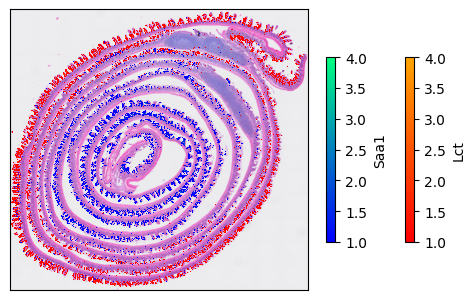

In [5]:
ax = si.plot.spatial("Lct", cmap=["red","orange"],figsize=(6,4),image=False,axis_labels=False,title="")
si.plot.spatial("Saa1", cmap="winter", ax=ax, title="",axis_labels=False)

### One to all
To find which genes are higher in one group in comparsison to all other groups. For example, genes that are specific to a celltype.

In [6]:
clust_8 = si.agg["SC"].dge("leiden",group1="8")
clust_8.loc[[clust_8['log2fc'].idxmin(), clust_8['log2fc'].idxmax()]]

Normalizing "8" spots
Normalizing "rest" spots
Number of entries in "8": 16809, in "rest": 237270


Running wilcox on [leiden]: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3222/3222 [00:52<00:00, 61.39it/s]


,log2fc,8,rest,pval_8,pval_rest,pval,qval,expression_mean,expression_min,expression_max,gene
Apoa1,-2.986161,0.000748,0.006239,0.0,1.0,0.0,0.0,0.003494,0.000748,0.006239,Apoa1
Itln1,2.531349,0.023806,0.004081,1.0,0.0,0.0,0.0,0.013943,0.004081,0.023806,Itln1


<Axes: title={'center': 'Defa21'}, xlabel='Spatial 1 (µm)', ylabel='Spatial 2 (µm)'>

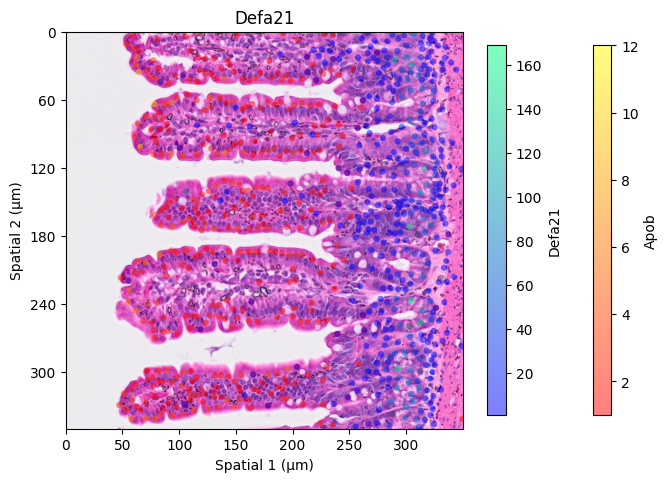

In [7]:
xlim = [0,350]
ylim = [3400,3750]
ax = si.agg["SC"].plot.spatial("Apob",xlim=xlim,ylim=ylim,size=20,cmap=["red","yellow"],alpha=0.5)
si.agg["SC"].plot.spatial("Defa21",xlim=xlim,ylim=ylim,size=20,ax=ax,alpha=0.5)

## Correlation analysis
For details on plotting the results visit notebook #4.

### Correlation of a single value
Performs spearman correlation on a gene or obs, with all genes. Good for exploring gene-grous that expressed together.

Ruuning it on fullsize bin-level data takes a long time, so it's recommended to work with single-cell level or crop the HiVis object (detail in notebook #1).

In [8]:
gene = "Iglc1"
cor_iglc1 = si.agg["SC"].cor("Iglc1",inplace=True)
cor_iglc1.head()

Computing correlation with Iglc1: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 3222/3222 [01:10<00:00, 45.44it/s]


,r,expression_mean,gene,pval,qval
0,0.004284,0.000172,Lypla1,0.030812,0.044699
1,0.004155,0.000180,Tcea1,0.036211,0.051808
2,0.001208,0.000181,Atp6v1h,0.542633,0.597842
3,-0.006936,0.000129,Cops5,0.000472,0.000890
4,-0.002738,0.000336,Arfgef1,0.167491,0.210886


<Axes: title={'center': 'Iglc1'}, xlabel='log10(mean expression)', ylabel='Spearman correlation'>

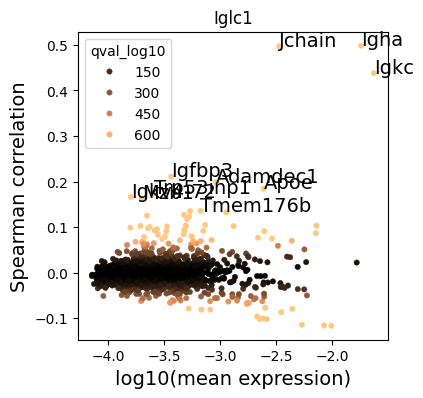

In [9]:
si.agg["SC"].plot.cor(gene,figsize=(4,4))

### Correlation matrix
Performs spearman correlation between a list of genes/obs. 

In [10]:
genes = ["Iglc1","Ang4","Defa21","Igkc","Jchain","Lyz1","Itln1"]
cor_matrix = si.agg["SC"].cor(genes)
cor_matrix

,Iglc1,Ang4,Defa21,Igkc,Jchain,Lyz1,Itln1
Iglc1,1.000000,-0.113786,-0.141051,0.190688,0.384143,-0.140349,-0.132705
Ang4,-0.113786,1.000000,0.545923,-0.154690,-0.065454,0.518340,0.526715
Defa21,-0.141051,0.545923,1.000000,-0.202023,-0.085088,0.542705,0.535338
Igkc,0.190688,-0.154690,-0.202023,1.000000,0.299679,-0.198665,-0.189851
Jchain,0.384143,-0.065454,-0.085088,0.299679,1.000000,-0.087253,-0.079851
Lyz1,-0.140349,0.518340,0.542705,-0.198665,-0.087253,1.000000,0.511212
Itln1,-0.132705,0.526715,0.535338,-0.189851,-0.079851,0.511212,1.000000


<Axes: >

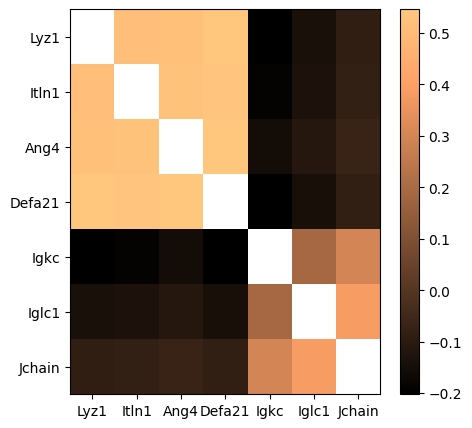

In [11]:
si.agg["SC"].plot.cor(genes,figsize=(5,5),cluster=True)

## Score genes
Works for both HiVis and Agg objects. Assigns score for each bin/object, based on a list of genes.

In [20]:
muscle_genes = ["Tpm2","Tpm1","Acta1","Myh11","Tagln","Des","Actg"]
si.agg["SC"].score_genes(muscle_genes, "muscle_score",z_normilize=False)

Cell_ID
00005473-2cfc-46a5-8f8c-4acadc4739b2   -1.577320
0000a59a-f65b-4f39-a9d5-9f9f7078d3bd   -0.350515
0001c2d0-6960-46a9-92d1-8c544c1f6aca   -0.164948
0001ee93-d06f-4e95-805c-512b4488fec1   -0.422680
000239ce-d5fb-456f-8f84-b02859d577b1   -0.020619
                                          ...   
fffd7267-950b-4db5-aee6-cbb54aaf3e1e   -0.113402
fffedc80-79b4-4115-b7d9-a8cca3be5237   -1.247423
ffff7df9-dc44-4a8c-aa10-e98d77e17666   -0.051546
ffffa94c-c28c-4598-8949-bb4748222b09    0.938144
fffff276-108b-42e8-99b7-6661fde3005f   -0.185567
Name: muscle_score, Length: 254079, dtype: float64

<Axes: title={'center': 'muscle_score'}, xlabel='Spatial 1 (µm)', ylabel='Spatial 2 (µm)'>

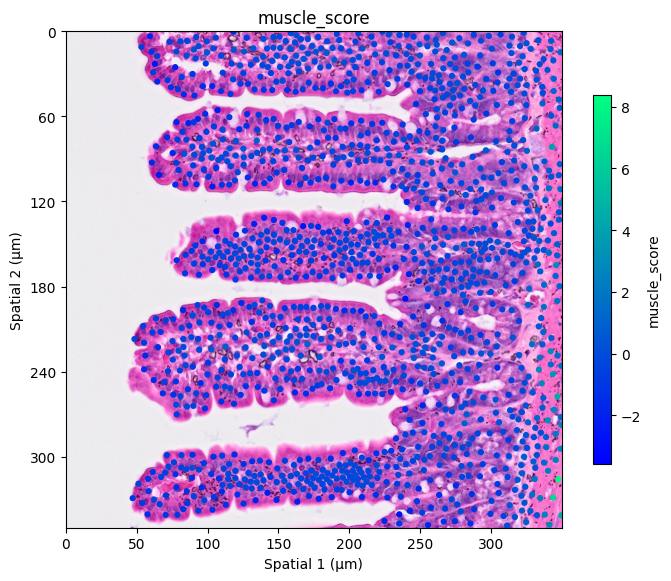

In [21]:
xlim = [0,350]
ylim = [3400,3750]
si.agg["SC"].plot.spatial("muscle_score",xlim=xlim,ylim=ylim,size=20)

## Smoothing
Since the data is sparse, in some cases we want to smooth the data spatially. This analysis smooths the values in specific radius. Notice that on bin-level data, since lots of values are 0, some filters may yiels only zeroes.

In [22]:
si.agg["SC"].smooth("muscle_score", radius=40, method="mean", new_col_name="muscle_score_smoothed")

mean filtering 'muscle_score' in radius 40: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 254079/254079 [00:03<00:00, 70048.26it/s]


[np.float64(-0.7047960555804572),
 np.float64(-0.2435724805386072),
 np.float64(-0.28215701823949246),
 np.float64(-0.5692168565744258),
 np.float64(-0.03104050476029519),
 np.float64(-0.7914432989690722),
 np.float64(1.7426023962106434),
 np.float64(-0.014122299110295135),
 np.float64(-0.9737915234822452),
 np.float64(-0.1442505947660587),
 np.float64(0.41024167652526616),
 np.float64(-0.22900529395374755),
 np.float64(0.6081476554705687),
 np.float64(-0.6753391209983722),
 np.float64(-0.44263622974963174),
 np.float64(-0.03627384406444842),
 np.float64(0.036989690721649496),
 np.float64(-0.8182077716098334),
 np.float64(-0.5006361044088615),
 np.float64(-0.8935006723442405),
 np.float64(-0.19129896907216495),
 np.float64(-0.38198219306466735),
 np.float64(-0.6352708927396359),
 np.float64(-0.9831913939937246),
 np.float64(1.9301423662248405),
 np.float64(-0.49339334978945837),
 np.float64(0.09819165117458174),
 np.float64(-0.029068483063328425),
 np.float64(-0.030186995135448744),
 n

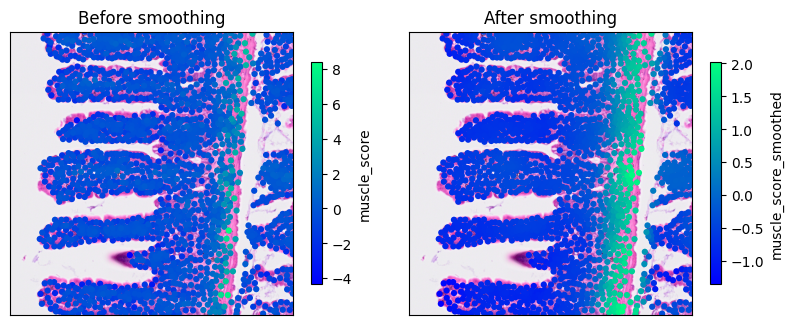

In [23]:
xlim = [0,450]
ylim = [3400,3850]

fig, axes = plt.subplots(1,2, figsize=(8,4))
si.agg["SC"].plot.spatial("muscle_score", xlim=xlim, ylim=ylim,ax=axes[0],title="Before smoothing",size=20,axis_labels=False)
si.agg["SC"].plot.spatial("muscle_score_smoothed", xlim=xlim, ylim=ylim,ax=axes[1],title="After smoothing",size=20,axis_labels=False)
plt.tight_layout()

## Noise-mean curve
This analysis help identify highly variable genes. It calculates the residual of each gene from linear model of the log10(CV),log10(expression).

Genes that have high residuals are "patchy", or non uniformally distributed.

In [24]:
hvg = si.noise_mean_curve(inplace=True)
hvg.head()

,gene,mean,mean_log,cv,cv_log,residual
0,Lypla1,0.003829,-2.416897,10.918015,1.134988,0.011781
1,Tcea1,0.002918,-2.534977,11.325783,1.147776,0.003508
2,Atp6v1h,0.003245,-2.488756,11.179501,1.143231,0.007208
3,Cops5,0.002287,-2.640649,11.552886,1.154738,-0.008378
4,Arfgef1,0.006239,-2.204895,9.789975,1.097514,0.012121


<Axes: xlabel='log10(mean expression)', ylabel='log10(CV)'>

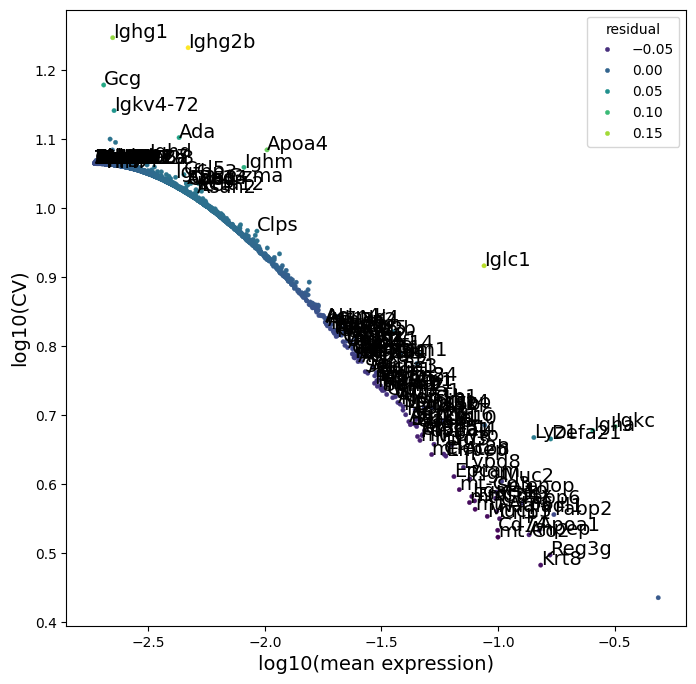

In [25]:
si.plot.noise_mean_curve()